## Part 3: Model Training & Evaluation


In [1]:
# --- Load prepared data (run project_notebook_v2_data_prep.ipynb first) ---
import json

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_pickle('artifacts/training_df.pkl')   # leakage-safe modelling frame (features + target)
with open('artifacts/feature_lists.json') as f:
    _fl = json.load(f)
numeric_features = _fl['numeric_features']
binary_features = _fl['binary_features']
categorical_features = _fl['categorical_features']
comorbidity_cols = _fl['comorbidity_cols']
feature_cols = _fl['feature_cols']

X = df[feature_cols]
y = df['target']
print(f"Loaded: df {df.shape} | X {X.shape}")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Age bands (defined with the EDA in Part 2; also needed here for the error analysis)
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 120]
age_labels = ['0-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

Loaded: df (260933, 18) | X (260933, 17)


## Section A Define Utils for model comparison 

In [2]:
# We save the test_train split before comparing any models to keep the evaluation fair
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index.to_numpy(),
    test_size=0.20,
    stratify=y, # to keep the test and train set with the same hospitalization rate
    random_state=RANDOM_STATE,
)

np.save('train_idx.npy', train_idx)
np.save('test_idx.npy', test_idx)

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
train_df = df.loc[train_idx]   

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # same split everywhere


def make_preprocessor():
    """Preprocessing shared by every model. has to be done fore every fold to prevent leakage with the scaling"""
    return ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])

## Section B Model Comparison

In [4]:
# we do gird search for hyperparameters we only do a search over the most impactful ones
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

scoring = ['roc_auc', 'average_precision', 'f1', 'recall']

models = {
    'Dummy (prior)':        (DummyClassifier(strategy='prior'), {}),
    'Logistic Regression':  (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                             {'clf__C': [0.1, 1, 10],
                              'clf__class_weight': [None, 'balanced']}),
    'Random Forest':        (RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                    random_state=RANDOM_STATE),
                             {'clf__max_depth': [10, 20, None],
                              'clf__min_samples_leaf': [1, 5],
                              'clf__max_features': ['sqrt', None]}),
    'Neural Network (MLP)': (MLPClassifier(early_stopping=True, max_iter=200,
                                           random_state=RANDOM_STATE),
                             {'clf__hidden_layer_sizes': [(32,), (64,), (128,)],
                              'clf__alpha': [1e-4, 1e-3],
                              'clf__learning_rate_init': [1e-3, 1e-2]}),
}

rows = []
for name, (clf, grid) in models.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', clf)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring=scoring, refit='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    i = gs.best_index_   
    rows.append({
        'model':       name,
        'best_params': gs.best_params_,
        'ROC_AUC':     gs.cv_results_['mean_test_roc_auc'][i],
        'PR_AUC':      gs.cv_results_['mean_test_average_precision'][i],
        'F1':          gs.cv_results_['mean_test_f1'][i],
        'Recall':      gs.cv_results_['mean_test_recall'][i],
    })

results = pd.DataFrame(rows).set_index('model').round(4)
results

,best_params,ROC_AUC,PR_AUC,F1,Recall
model,,,,,
Dummy (prior),{},0.5000,0.2343,0.0000,0.0000
Logistic Regression,"{'clf__C': 10, 'clf__class_weight': 'balanced'}",0.7955,0.5685,0.5564,0.7297
Random Forest,"{'clf__max_depth': 20, 'clf__max_features': 's...",0.8213,0.6116,0.5229,0.4267
Neural Network (MLP),"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes...",0.8236,0.6162,0.5304,0.4376


## Section C — Final Pipeline, Cross-Validation & Hyperparameter Search

In [5]:
import optuna
from sklearn.model_selection import cross_val_score

N_TRIALS = 30


def make_mlp(trial):
    """Build an MLPClassifier from an Optuna trial (also works with a FixedTrial for the refit)."""
    n_layers = trial.suggest_int('n_layers', 1, 2)
    hidden = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256, log=True)
                   for i in range(n_layers))
    return MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=trial.suggest_float('alpha', 1e-6, 1e-1, log=True),
        learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        batch_size=trial.suggest_categorical('batch_size', [128, 256, 512]),
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
        max_iter=200, random_state=RANDOM_STATE,
    )


def objective(trial):
    pipe = Pipeline([('prep', make_preprocessor()), ('clf', make_mlp(trial))])
    return cross_val_score(pipe, X_train, y_train, cv=cv,
                           scoring='roc_auc', n_jobs=-1).mean()


optuna.logging.set_verbosity(optuna.logging.WARNING)   # keep the notebook output readable
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Trials: {len(study.trials)}  |  Total CV fits: {len(study.trials) * cv.get_n_splits()}")
print(f"\nBest CV ROC-AUC within training on validation: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k} = {v}")

# Refit the best configuration on the full training set
best_model = Pipeline([
    ('prep', make_preprocessor()),
    ('clf', make_mlp(optuna.trial.FixedTrial(study.best_params))),
]).fit(X_train, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

Trials: 30  |  Total CV fits: 150

Best CV ROC-AUC within training on validation: 0.8237
Best hyperparameters:
  n_layers = 2
  n_units_l0 = 108
  n_units_l1 = 69
  alpha = 0.0095200611516019
  learning_rate_init = 0.0003074326026550764
  batch_size = 512


In [6]:
# # For development
# best_params = {
#     'n_layers': 1,
#     'n_units_l0': 176,
#     'alpha': 0.0004218279954930134,
#     'learning_rate_init': 0.001563469271718208,
#     'batch_size': 512,
# }
# 
# hidden = tuple(best_params[f'n_units_l{i}'] for i in range(best_params['n_layers']))
# 
# best_model = Pipeline([
#     ('prep', make_preprocessor()),
#     ('clf', MLPClassifier(
#         hidden_layer_sizes=hidden,
#         alpha=best_params['alpha'],
#         learning_rate_init=best_params['learning_rate_init'],
#         batch_size=best_params['batch_size'],
#         early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
#         max_iter=200, random_state=RANDOM_STATE,
#     )),
# ]).fit(X_train, y_train)
# 
# print("best_model trained on the full training set with the fixed best hyperparameters.")

## Section D Evaluation on Train and threshold calculation

In [7]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, balanced_accuracy_score,
                             brier_score_loss, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay


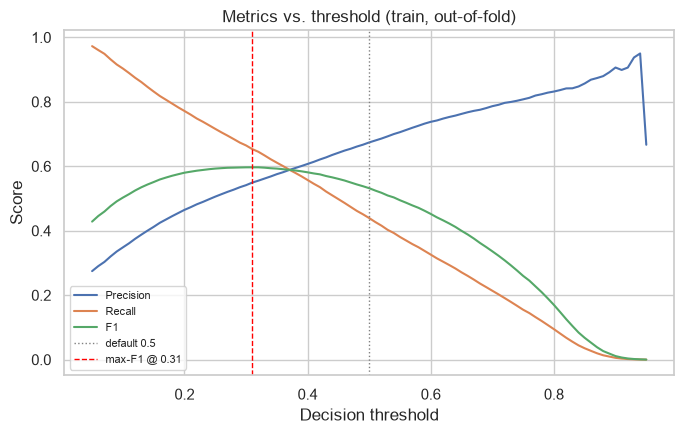

Operating threshold chosen on training OOF data: 0.31  (precision=0.549, recall=0.653, F1=0.597)


In [8]:


thresholds = np.linspace(0.05, 0.95, 91)
oof_proba = cross_val_predict(clone(best_model), X_train, y_train,
                              cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

prec_t, rec_t, f1_t = [], [], []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    prec_t.append(precision_score(y_train, pred_t, zero_division=0))
    rec_t.append(recall_score(y_train, pred_t, zero_division=0))
    f1_t.append(f1_score(y_train, pred_t, zero_division=0))
best_t_train = float(thresholds[int(np.argmax(f1_t))])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, prec_t, label="Precision")
ax.plot(thresholds, rec_t, label="Recall")
ax.plot(thresholds, f1_t, label="F1")
ax.axvline(0.5, color='grey', ls=':', lw=1, label="default 0.5")
ax.axvline(best_t_train, color='red', ls='--', lw=1, label=f"max-F1 @ {best_t_train:.2f}")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs. threshold (train, out-of-fold)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

CHOSEN_THRESHOLD = best_t_train   
pred_bt = (oof_proba >= best_t_train).astype(int)
print(f"Operating threshold chosen on training OOF data: {CHOSEN_THRESHOLD:.2f}  "
      f"(precision={precision_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"recall={recall_score(y_train, pred_bt, zero_division=0):.3f}, "
      f"F1={f1_score(y_train, pred_bt, zero_division=0):.3f})")

In [9]:
# add calculated threshold to model
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import FixedThresholdClassifier

final_model = FixedThresholdClassifier(
    FrozenEstimator(best_model), threshold=CHOSEN_THRESHOLD,
).fit(X_train, y_train)

 Cross-validated training performance
Threshold-free metrics:
ROC-AUC                0.823
PR-AUC                 0.617
Brier score            0.130

Threshold-dependent metrics: chosen threshold 0.31 vs. default 0.50
                      @ 0.31    @ 0.50
F1                     0.597     0.532
Precision              0.549     0.674
Recall                 0.653     0.439
Balanced accuracy      0.745     0.687


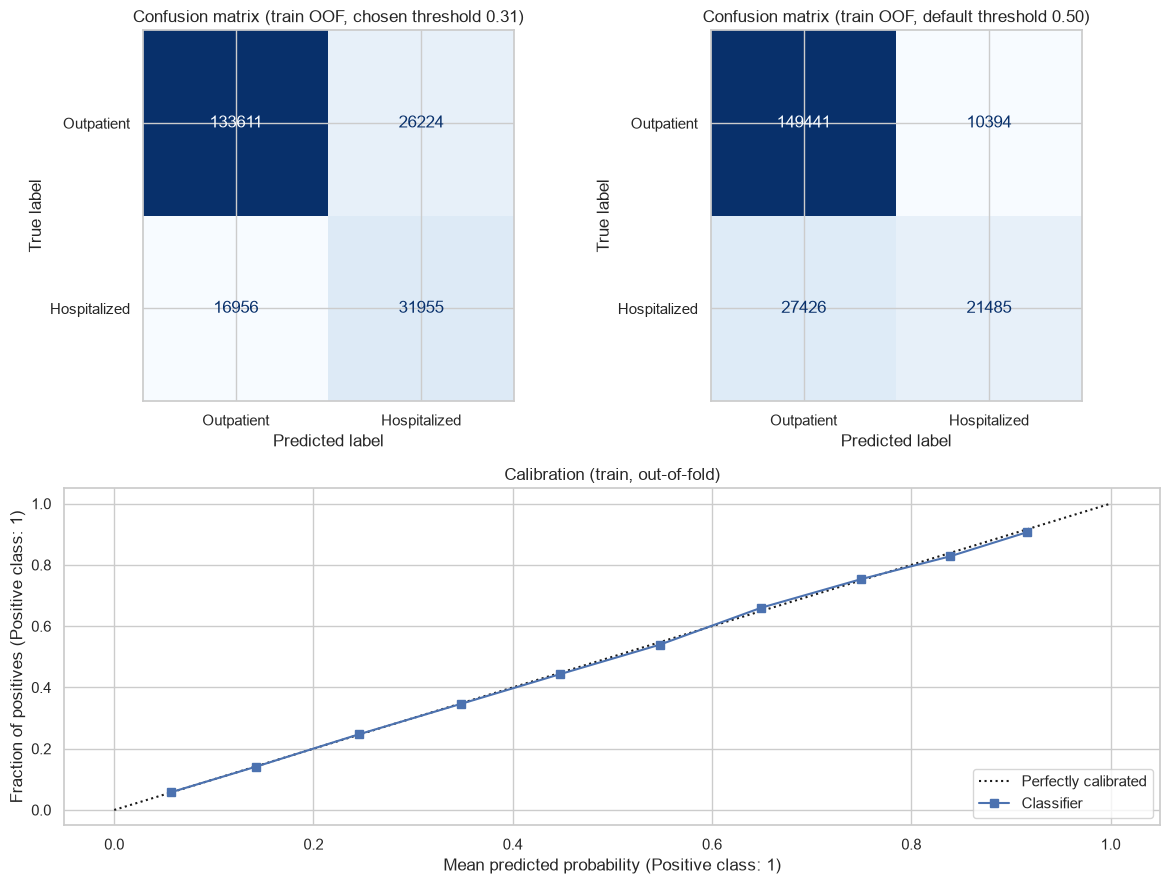

In [17]:
# confusion matrix with default and calculated threshold
oof_pred = (oof_proba >= CHOSEN_THRESHOLD).astype(int)
oof_pred_05 = (oof_proba >= 0.5).astype(int)

print(" Cross-validated training performance")
print("Threshold-free metrics:")
print(f"{'ROC-AUC':18s}{roc_auc_score(y_train, oof_proba):>10.3f}")
print(f"{'PR-AUC':18s}{average_precision_score(y_train, oof_proba):>10.3f}")
print(f"{'Brier score':18s}{brier_score_loss(y_train, oof_proba):>10.3f}")

print(f"\nThreshold-dependent metrics: chosen threshold {CHOSEN_THRESHOLD:.2f} vs. default 0.50")
print(f"{'':18s}{'@ ' + format(CHOSEN_THRESHOLD, '.2f'):>10s}{'@ 0.50':>10s}")
print(f"{'F1':18s}{f1_score(y_train, oof_pred):>10.3f}{f1_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Precision':18s}{precision_score(y_train, oof_pred):>10.3f}{precision_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Recall':18s}{recall_score(y_train, oof_pred):>10.3f}{recall_score(y_train, oof_pred_05):>10.3f}")
print(f"{'Balanced accuracy':18s}{balanced_accuracy_score(y_train, oof_pred):>10.3f}{balanced_accuracy_score(y_train, oof_pred_05):>10.3f}")

fig, axes = plt.subplot_mosaic([['cm_chosen', 'cm_05'], ['cal', 'cal']],
                               figsize=(12, 9), height_ratios=[1.1, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_chosen'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_chosen'].set_title(f'Confusion matrix (train OOF, chosen threshold {CHOSEN_THRESHOLD:.2f})')
ConfusionMatrixDisplay(
    confusion_matrix(y_train, oof_pred_05),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes['cm_05'], colorbar=False, cmap='Blues', values_format='d')
axes['cm_05'].set_title('Confusion matrix (train OOF, default threshold 0.50)')
CalibrationDisplay.from_predictions(y_train, oof_proba, n_bins=10, ax=axes['cal'])
axes['cal'].set_title('Calibration (train, out-of-fold)')
plt.tight_layout(); plt.show()

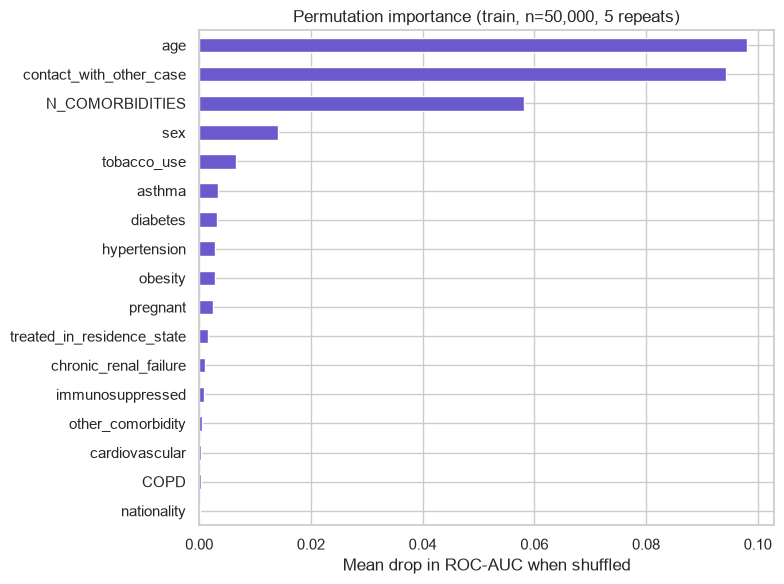

In [11]:
# was used to evaluate different parameters to add or remove 
from sklearn.inspection import permutation_importance

rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_train))
sub = rng.choice(len(X_train), size=n_pi, replace=False)
pi_train = permutation_importance(best_model, X_train.iloc[sub], y_train.iloc[sub],
                                  scoring='roc_auc', n_repeats=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)
imp_train = (pd.Series(pi_train.importances_mean, index=X_train.columns)
             .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
imp_train.plot.barh(ax=ax, color='slateblue')
ax.set_xlabel("Mean drop in ROC-AUC when shuffled")
ax.set_title(f"Permutation importance (train, n={n_pi:,}, 5 repeats)")
plt.tight_layout(); plt.show()

## Section E Evaluation on the Holdout set

Hold-out test performance 
ROC-AUC  : 0.823
PR-AUC   : 0.610
F1       : 0.595
Precision: 0.566
Recall   : 0.626


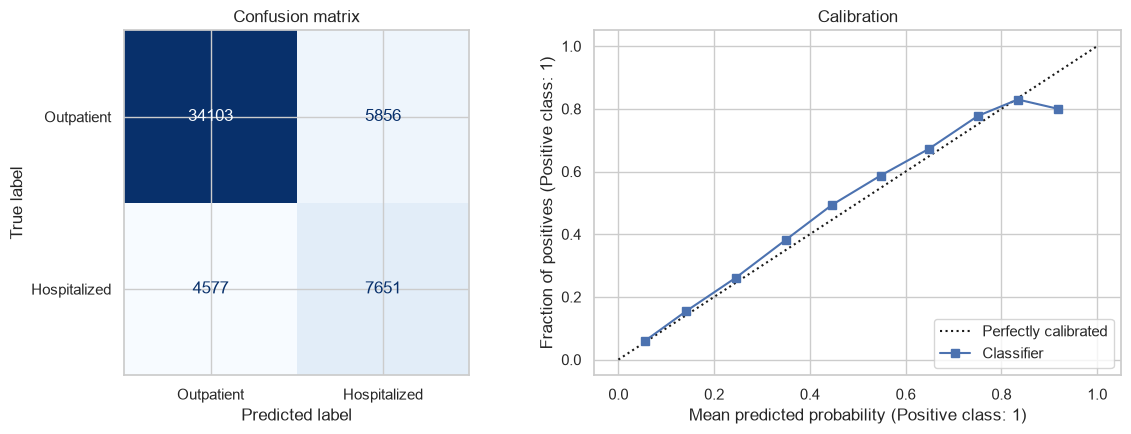

In [18]:
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             recall_score, precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibrationDisplay

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = final_model.predict(X_test)   

print("Hold-out test performance ")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, test_proba):.3f}")
print(f"F1       : {f1_score(y_test, test_pred):.3f}")
print(f"Precision: {precision_score(y_test, test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, test_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, test_pred),
    display_labels=['Outpatient', 'Hospitalized'],
).plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Confusion matrix')
CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10, ax=axes[1])
axes[1].set_title('Calibration')
plt.tight_layout(); plt.show()

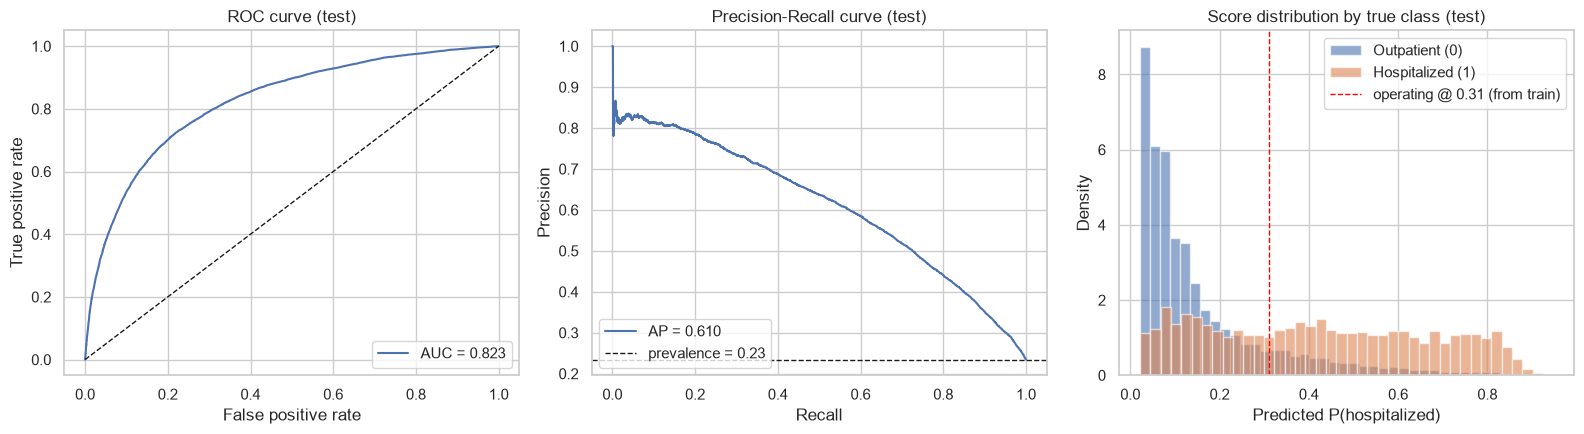

In [19]:
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, f1_score, precision_score, recall_score)

proba = final_model.predict_proba(X_test)[:, 1]   

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve (test)"); axes[0].legend(loc="lower right")

# (2) Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f"prevalence = {y_test.mean():.2f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (test)"); axes[1].legend(loc="lower left")

# (3) Predicted-probability distribution by true class
axes[2].hist(proba[y_test.to_numpy() == 0], bins=40, alpha=0.6, density=True, label="Outpatient (0)")
axes[2].hist(proba[y_test.to_numpy() == 1], bins=40, alpha=0.6, density=True, label="Hospitalized (1)")
axes[2].axvline(CHOSEN_THRESHOLD, color='red', ls='--', lw=1,
                label=f"operating @ {CHOSEN_THRESHOLD:.2f} (from train)")
axes[2].set_xlabel("Predicted P(hospitalized)"); axes[2].set_ylabel("Density")
axes[2].set_title("Score distribution by true class (test)"); axes[2].legend()

plt.tight_layout(); plt.show()

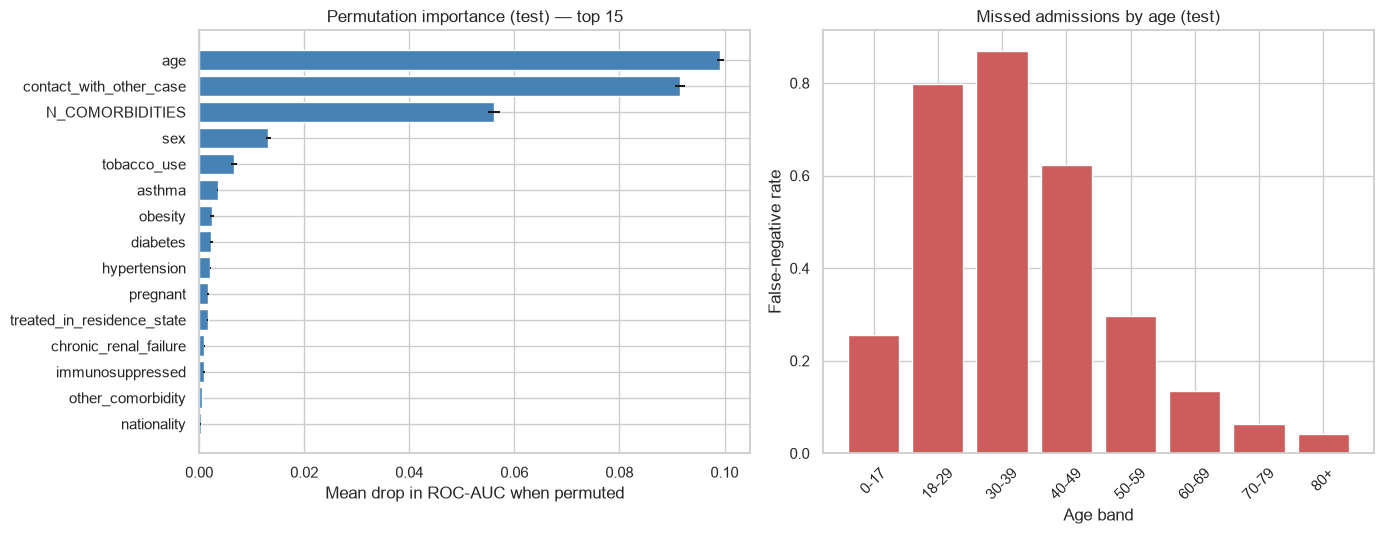

In [20]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (left) Permutation feature importance
rng = np.random.RandomState(RANDOM_STATE)
n_pi = min(50000, len(X_test))
sub = rng.choice(len(X_test), size=n_pi, replace=False)
pi = permutation_importance(best_model, X_test.iloc[sub], y_test.iloc[sub],
                            scoring='roc_auc', n_repeats=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values().tail(15)
axes[0].barh(imp.index, imp.values,
             xerr=pd.Series(pi.importances_std, index=X_test.columns).loc[imp.index],
             color='steelblue')
axes[0].set_xlabel("Mean drop in ROC-AUC when permuted")
axes[0].set_title("Permutation importance (test) — top 15")

# (right) False-negative rate by age band
tmp = pd.DataFrame({'age': X_test['age'].to_numpy(),
                    'y_true': y_test.to_numpy(), 'y_pred': test_pred})
tmp['age_band'] = pd.cut(tmp['age'], bins=age_bins, labels=age_labels, right=False)
pos = tmp[tmp['y_true'] == 1]
fn_rate = pos.groupby('age_band', observed=True)['y_pred'].apply(lambda s: (s == 0).mean())
axes[1].bar(fn_rate.index.astype(str), fn_rate.values, color='indianred')
axes[1].set_xlabel("Age band"); axes[1].set_ylabel("False-negative rate")
axes[1].set_title("Missed admissions by age (test)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


In [21]:
# Error per different feature (age,sex,# comorbidities)
err = X_test.copy()
err['y_true'] = y_test.values
err['y_pred'] = test_pred
err['age_band'] = pd.cut(err['age'], bins=age_bins, labels=age_labels, right=False)
err['n_comorb'] = err[comorbidity_cols].fillna(0).sum(axis=1).clip(upper=4).astype(int)


def group_report(col):
    def summarize(sub):
        pos = sub['y_true'] == 1
        false_neg = (pos & (sub['y_pred'] == 0)).sum()
        return pd.Series({
            'n': len(sub),
            'error_rate': 1 - (sub['y_true'] == sub['y_pred']).mean(),
            'false_neg_rate': false_neg / max(int(pos.sum()), 1),
        })
    return err.groupby(col, observed=True).apply(summarize, include_groups=False).round(3)


for col in ['age_band', 'sex', 'n_comorb']:
    print(f"\n=== Error by {col} ===")
    print(group_report(col))


=== Error by age_band ===
                n  error_rate  false_neg_rate
age_band                                     
0-17       2532.0       0.243           0.255
18-29      8890.0       0.087           0.799
30-39     12608.0       0.115           0.870
40-49     11587.0       0.202           0.623
50-59      8442.0       0.311           0.297
60-69      4586.0       0.331           0.135
70-79      2299.0       0.313           0.063
80+        1243.0       0.313           0.041

=== Error by sex ===
           n  error_rate  false_neg_rate
sex                                     
0    25629.0       0.169           0.437
1    26558.0       0.230           0.333

=== Error by n_comorb ===
                n  error_rate  false_neg_rate
n_comorb                                     
0         29295.0       0.151           0.599
1         13508.0       0.235           0.362
2          6069.0       0.293           0.196
3          2328.0       0.323           0.112
4           987.0       

In [22]:
import sklearn, matplotlib, seaborn, plotly, optuna

print("Library versions")
for m in [np, pd, sklearn, matplotlib, seaborn, plotly, optuna]:
    print(f"  {m.__name__}: {m.__version__}")

print(f"\nRANDOM_STATE = {RANDOM_STATE}")
print("Saved split indices: train_idx.npy, test_idx.npy")
print(f"Reload check: train={len(np.load('train_idx.npy')):,}, "
      f"test={len(np.load('test_idx.npy')):,}")

Library versions
  numpy: 2.5.0
  pandas: 3.0.3
  sklearn: 1.9.0
  matplotlib: 3.11.0
  seaborn: 0.13.2
  plotly: 6.8.0
  optuna: 4.9.0

RANDOM_STATE = 42
Saved split indices: train_idx.npy, test_idx.npy
Reload check: train=208,746, test=52,187
